In [1]:
import os
# Set these FIRST, before any other imports
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_GPU_THREAD_MODE'] = 'gpu_private'
os.environ['TF_GPU_THREAD_COUNT'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Disable GPU if you're using CPU

# Now import everything else
import pandas as pd
import numpy as np
import librosa
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for SSH
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_hub as hub

/wynton/home/zhang/sli21/.conda/envs/r2d2/lib/python3.9/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
audio_root = "Merged"  # folder that contains the WAVs

df = pd.read_csv("data_full.csv")

# Basic cleaning/encoding for the columns you showed
df["Sex"] = df["Sex"].map({"Male": 0, "Female": 1})
df["qxr_radiologist"] = df["qxr_radiologist"].map({"Normal": 0, "Abnormal": 1})
df["Diabetes"] = df["Diabetes"].map({"Non Diabetic": 0, "Diabetic": 1})

bin_cols = [
    "Breathsounds", "Breathdifficulty", "Priortb", "Hemoptysis",
    "Weightloss", "Smokedinlastweek", "Fever", "Nightsweats"
]
df[bin_cols] = df[bin_cols].apply(lambda x: x.map({"Yes": 1, "No": 0}))

# BMI (already in your sample, but recompute if needed)
df["BMI"] = np.round(df["Weight"] / (0.01 * df["Height"])**2, 2)

# Drop rows without label
df = df.dropna(subset=["qxr_radiologist"])

print("N records:", len(df))
print("Class balance:\n", df["qxr_radiologist"].value_counts())

df

N records: 1078
Class balance:
 qxr_radiologist
1.0    577
0.0    501
Name: count, dtype: int64


,Country,StudyID,Sex,Age,Height,Weight,Diabetes,HIVstatus,Durationofcough,Priortb,...,Temperature,Weightloss,Smokedinlastweek,Fever,Nightsweats,Breathsounds,Breathdifficulty,qxr_radiologist,audio_file,BMI
0,PH,R2D2011001,1,47,158.5,70.0,0,Negative,21,1.0,...,36.8,1,0,1,1,1,1,0.0,Merged/Rec_R2D2011001_23_12_06_08_12_15_XA_XI.WAV,27.86
1,PH,R2D2011002,1,41,150.0,48.5,0,Negative,0,0.0,...,36.8,0,0,0,0,0,0,1.0,Merged/Rec_R2D2011002_23_12_07_14_39_31_XA_M20...,21.56
2,PH,R2D2011003,0,50,157.0,54.5,1,Negative,30,1.0,...,36.7,1,1,0,1,1,0,1.0,Merged/Rec_R2D2011003_23_12_11_14_58_49_XA_M20...,22.11
3,PH,R2D2011007,0,48,179.0,79.5,0,Negative,240,0.0,...,37.0,1,1,1,1,1,1,1.0,Merged/Rec_R2D2011007_23_12_13_15_27_18_XA_M20...,24.81
4,PH,R2D2011009,1,63,151.5,62.9,0,Negative,30,0.0,...,36.7,1,0,1,1,1,1,0.0,Merged/Rec_R2D2011009_23_12_13_15_52_58_XA_M20...,27.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1088,IN,R2D205957,0,47,169.0,44.4,1,Negative,30,1.0,...,36.5,1,0,0,0,1,1,1.0,Merged/Rec_R2D205957_24_02_23_15_21_31_XA_moto...,15.55
1089,IN,R2D205958,0,64,168.0,68.5,0,Negative,30,0.0,...,36.6,0,0,1,1,1,1,1.0,Merged/Rec_R2D205958_24_02_23_16_14_03_XA_moto...,24.27
1090,IN,R2D205959,0,52,177.0,63.2,0,Negative,90,0.0,...,37.2,0,0,0,0,0,1,1.0,Merged/Rec_R2D205959_24_02_28_09_37_09_XA_moto...,20.17
1091,IN,R2D205960,1,32,154.0,48.4,0,Negative,180,0.0,...,37.0,1,0,1,0,0,0,1.0,Merged/Rec_R2D205960_24_02_26_13_35_00_XA_moto...,20.41


# Extract from top 5 longest segments per patient

In [3]:
SAMPLING_RATE = 16000  # HeAR uses 16kHz
SEGMENT_DURATION = 2.0  # Process 2-second chunks
MIN_SEGMENT_LENGTH = 0.32  # Minimum 0.1 seconds, 0.32
BANDPASS_LOW = 100
BANDPASS_HIGH = 7500

audio_root = "Merged"

from huggingface_hub import login
from transformers import AutoImageProcessor, AutoModel
import torch
from dotenv import load_dotenv

load_dotenv()
hf_token = os.getenv("HF_token")

login(token=hf_token)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


print("Loading HeAR model (TensorFlow)...")
from huggingface_hub import from_pretrained_keras
import tensorflow as tf

# Load the model once (global scope)
tf_model = from_pretrained_keras("google/hear")
hear_inference = tf_model.signatures['serving_default']

/wynton/home/zhang/sli21/.conda/envs/r2d2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Loading HeAR model (TensorFlow)...


Fetching 24 files: 100%|██████████| 24/24 [00:00<00:00, 65.74it/s]


In [4]:
from scipy.signal import butter, filtfilt

def apply_bandpass_filter(audio, sr=SAMPLING_RATE, low=BANDPASS_LOW, high=BANDPASS_HIGH):
    """Apply bandpass filter to isolate relevant frequencies"""
    nyquist = 0.5 * sr
    low_norm = low / nyquist
    high_norm = high / nyquist
    b, a = butter(5, [low_norm, high_norm], btype='band')
    return filtfilt(b, a, audio)

def segment_audio(audio, sr=SAMPLING_RATE, top_db=21):
    """Split audio into non-silent segments"""
    intervals = librosa.effects.split(audio, top_db=top_db)
    segments = [audio[start:end] for start, end in intervals]
    return segments

def preprocess_audio(file_path):
    """
    Load and preprocess audio file
    Returns: List of filtered audio segments
    """
    try:
        # Load at 16kHz (HeAR's expected rate)
        audio, _ = librosa.load(file_path, sr=SAMPLING_RATE, mono=True)
        
        # Apply bandpass filter
        audio_filtered = apply_bandpass_filter(audio)
        
        # Split into segments
        segments = segment_audio(audio_filtered)
        
        # Filter by minimum length
        min_samples = int(MIN_SEGMENT_LENGTH * SAMPLING_RATE)
        valid_segments = [s for s in segments if len(s) >= min_samples]
        
        # Fallback: use entire filtered audio if no valid segments
        if not valid_segments:
            valid_segments = [audio_filtered]
            
        return valid_segments
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return []

In [5]:
def prepare_audio_for_hear(segment, target_length=None):
    """
    Prepare audio segment for HeAR model
    HeAR expects: 1D waveform at 16kHz
    """
    if target_length is None:
        target_length = int(SEGMENT_DURATION * SAMPLING_RATE)  # 32000 samples = 2 seconds
    
    # Pad or truncate to target length
    if len(segment) < target_length:
        segment = np.pad(segment, (0, target_length - len(segment)), mode='constant')
    else:
        segment = segment[:target_length]
    
    # Normalize amplitude to [-1, 1]
    if np.abs(segment).max() > 0:
        segment = segment / np.abs(segment).max()
    
    return segment

def get_hear_embedding(audio_segment):
    """
    Extract embedding using HeAR (TensorFlow version)
    Input: 1D numpy array (audio waveform), target 32000 samples
    """
    try:
        # 1. Prepare audio: Pad/Trim to exactly 2 seconds (32,000 samples)
        target_length = 32000
        if len(audio_segment) < target_length:
            # Pad with zeros if too short
            audio_prepared = np.pad(audio_segment, (0, target_length - len(audio_segment)), mode='constant')
        else:
            # Truncate if too long
            audio_prepared = audio_segment[:target_length]

        # if np.abs(audio_prepared).max() > 0:
        #     audio_prepared = audio_prepared / np.abs(audio_prepared).max()

        # 2. Convert to Tensor and add Batch Dimension: (1, 32000)
        # Ensure float32 data type
        audio_tensor = tf.convert_to_tensor(audio_prepared, dtype=tf.float32)
        audio_tensor = tf.reshape(audio_tensor, [1, 32000])

        # 3. Inference
        # The Keras model signature returns a dict. Key 'output_0' is usually the embedding.
        outputs = hear_inference(x=audio_tensor)
        
        # Extract embedding and flatten to 1D array
        embedding = outputs['output_0'].numpy().flatten()
        
        return embedding

    except Exception as e:
        print(f"Error extracting embedding: {e}")
        return None

In [6]:
print("\nTesting embedding extraction...")
test_audio = np.random.randn(32000).astype(np.float32)  # 2 seconds of random audio
test_embedding = get_hear_embedding(test_audio)

if test_embedding is not None:
    print(f"✓ Test successful! Embedding shape: {test_embedding.shape}")
    embedding_dim = test_embedding.shape[0]
    print(f"Embedding dimension: {embedding_dim}")
else:
    print("✗ Test failed")
    embedding_dim = None


Testing embedding extraction...


I0000 00:00:1772138770.944429  153584 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


✓ Test successful! Embedding shape: (512,)
Embedding dimension: 512


In [7]:
print(f"\nExtracting Test Segments ...")
test = df.iloc[0]
test_segments = preprocess_audio(test['audio_path'])
test_segments.sort(key=len, reverse=True)
top_test_segments = test_segments[:5]


Extracting Test Segments ...


# Load Sample Segments

In [8]:
import IPython.display as ipd
import librosa.display
import matplotlib.pyplot as plt

print(f"Playing top {len(top_test_segments)} segments from the last subject...")

for i, seg in enumerate(top_test_segments):
    print(f"\n--- Segment {i+1} ---")
    
    # 2. Visualize the waveform (optional but helpful to see cough spikes)
    plt.figure(figsize=(10, 2))
    librosa.display.waveshow(seg, sr=SAMPLING_RATE)
    plt.title(f"Segment {i+1} Waveform")
    plt.show()
    
    # 3. Create the Audio Player
    # Note: Use ipd.display() to ensure all players show up in one cell
    ipd.display(ipd.Audio(data=seg, rate=SAMPLING_RATE))

Playing top 4 segments from the last subject...

--- Segment 1 ---



--- Segment 2 ---



--- Segment 3 ---



--- Segment 4 ---


# Extract Acoustic Features 

In [10]:
# https://ieeexplore.ieee.org/document/9413989
from scipy.stats import entropy, kurtosis, skew
import parselmouth
from parselmouth.praat import call

def extract_audio_features(audio, sr=SAMPLING_RATE):
    """
    Extract multiple types of audio features for robust classification
    """

    N_FFT = 128
    HOP_LENGTH = 64 #or 64
    N_MELS = 20
    N_MFCC = 20

    if len(audio) < N_FFT:
        print("short")

    features = {}

    snd = parselmouth.Sound(audio, sampling_frequency=sr)
    # pitch object (for jitter/shimmer)
    point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)

    # basic voice-quality measures
    jitter_local   = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
    shimmer_local  = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    hnr            = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
    hnr_mean       = call(hnr, "Get mean", 0, 0)

    # formants via Burg’s method
    formant = call(snd, "To Formant (burg)", 0.0, 4, 5500, 0.025, 50)
    # average over segment
    formant_means = [call(formant, "Get mean", i, 0, 0, "Hertz") 
                     for i in range(1, 5)]  # F1–F4

    features.update({
        "jitter": jitter_local,
        "shimmer": shimmer_local,
        "hnr": hnr_mean,
        **{f"F{i}": formant_means[i-1] for i in range(1,5)}
    })


    # 1. MFCC Features (13 coefficients + derivatives)
    # print("Extracting MFCC features...")
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    
    mfcc_delta = librosa.feature.delta(mfccs)
    mfcc_delta2 = librosa.feature.delta(mfccs, order=2)
    
    # Statistical measures of MFCCs, extract fro each coefficient
    # 78 features
    features.update({
        'mfcc_mean': np.mean(mfccs, axis=1),
        'mfcc_std': np.std(mfccs, axis=1),
        'mfcc_delta_mean': np.mean(mfcc_delta, axis=1),
        'mfcc_delta_std': np.std(mfcc_delta, axis=1),
        'mfcc_delta2_mean': np.mean(mfcc_delta2, axis=1),
        'mfcc_delta2_std': np.std(mfcc_delta2, axis=1)
    })
    
    # 2. Spectral Features
    # print("Extracting Spectral features...")
    spectral_centroids = librosa.feature.spectral_centroid(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]
    spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectral_flatness = librosa.feature.spectral_flatness(y=audio, n_fft=N_FFT, hop_length=HOP_LENGTH)[0]

    features.update({
        'spectral_centroid_mean': np.mean(spectral_centroids),
        'spectral_centroid_std': np.std(spectral_centroids),
        'spectral_bandwidth_mean': np.mean(spectral_bandwidth),
        'spectral_bandwidth_std': np.std(spectral_bandwidth),
        'spectral_rolloff_mean': np.mean(spectral_rolloff),
        'spectral_rolloff_std': np.std(spectral_rolloff),
        'spectral_contrast_mean': np.mean(spectral_contrast, axis=1), #7 default
        'spectral_contrast_std': np.std(spectral_contrast, axis=1),
        'spectral_flatness_mean': np.mean(spectral_flatness),
        'spectral_flatness_std': np.std(spectral_flatness),
    })
    
    # 3. Rhythm and Temporal Features
    # print("Extracting Rhythm and Temporal features...")
    zero_crossing_rate = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)[0]
    rms_energy = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)[0]

    features.update({
        'zcr_mean': np.mean(zero_crossing_rate),
        'zcr_std': np.std(zero_crossing_rate),
        'rms_energy_mean': np.mean(rms_energy), 
        'rms_energy_std': np.std(rms_energy),
    })
    
    # 4. Chroma and Tonal Features
    # print("Extracting Chroma and Tonal features...")
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    
    features.update({
        'chroma_mean': np.mean(chroma, axis=1), #12 one per chroma bin
        'chroma_std': np.std(chroma, axis=1)
    })
    
    # 5. Energy and Power Features
    # 4 features
    # print("Extracting Energy and Power features...")
    features.update({
        'total_energy': np.sum(audio**2),
        'max_amplitude': np.max(np.abs(audio))
    })
    
    # 6. Mel-scale Features
    # 80 features
    # print("Extracting Mel-scale features...")
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=N_FFT, n_mels=N_MELS)
    mel_features = librosa.power_to_db(mel_spectrogram)
    
    features.update({
        'mel_mean': np.mean(mel_features, axis=1),
        'mel_std': np.std(mel_features, axis=1)
    })
    
    #7. Time-domain features
    # 3 total
    # print("Extracting Time-domain features...")
    features.update({
        'entropy': entropy(np.abs(audio)), 
        'kurtosis': kurtosis(audio),
        'skewness': skew(audio)
    })

    #8. STFT
    stft = np.abs(librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH))
    features.update({
        'stft_mean': np.mean(stft),
        'stft_std': np.std(stft),
        'stft_skew': skew(stft.flatten()),
        'stft_kurtosis': kurtosis(stft.flatten())
    })
    
    return features

def flatten_features(feature_dict, sample_id=None):
    """
    Flatten nested feature dictionary into a single-row DataFrame
    """
    flat_dict = {}
    
    for key, value in feature_dict.items():
        if isinstance(value, np.ndarray):
            for i, v in enumerate(value):
                flat_dict[f"{key}_{i}"] = v
        else:
            flat_dict[key] = value
    
    df = pd.DataFrame([flat_dict])
    if sample_id is not None:
        df.index = [sample_id]
    
    return df

In [11]:
from tqdm import tqdm

# Feature extraction
acoustic_features_df = []
max_length = 5124

segments = dict()

all_segment_data = [] # Changed name to reflect segment-level storage
failed_files = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing Acoustic Features"):
    try:
        segments = preprocess_audio(row['audio_path'])
        
        if not segments:
            failed_files.append(row['audio_path'])
            continue
        
        # Take top 5 longest segments
        segments.sort(key=len, reverse=True)
        top_segments = segments[:5]
        
        segment_count = 0
        for seg in top_segments:
            features_dict = extract_audio_features(seg, SAMPLING_RATE)
            # Create a feature dictionary for EACH segment       
            feature_df = flatten_features(features_dict)
            feature_df['subject_id'] = idx 
            feature_df['segment_id'] = segment_count
            feature_df['label'] = row['qxr_radiologist']
            acoustic_features_df.append(feature_df)
            segment_count += 1
        if segment_count == 0:
            failed_files.append(row['audio_path'])

    except Exception as e:
        print(f"Error processing subject {idx}: {e}")
        failed_files.append(row['audio_path'])

acoustic_features_df = pd.concat(acoustic_features_df, ignore_index=True)
# acoustic_features_df.to_csv('acoustic_features_segment_full_hear.csv', index=False)
acoustic_features_df


Processing Acoustic Features: 100%|██████████| 1078/1078 [05:31<00:00,  3.25it/s]


,jitter,shimmer,hnr,F1,F2,F3,F4,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,...,entropy,kurtosis,skewness,stft_mean,stft_std,stft_skew,stft_kurtosis,subject_id,segment_id,label
0,NaN,NaN,-0.697620,1306.556958,2237.775546,3621.738319,4870.283576,-161.449840,12.690631,-3.485057,...,8.428848,4.872574,0.302011,0.380708,0.545445,4.707702,47.661837,0,0,0.0
1,0.081879,0.325525,-2.081945,1238.845526,2232.394476,3690.478051,4765.494069,-156.432152,16.003787,-2.395842,...,8.347608,2.514651,0.057357,0.399249,0.551754,3.691823,28.839548,0,1,0.0
2,NaN,NaN,-1.376723,1366.781190,2548.023163,3674.787614,4954.177757,-158.302775,11.122177,-4.638164,...,8.324901,3.927223,-0.000127,0.323573,0.446690,4.893508,61.760139,0,2,0.0
3,0.074447,0.188300,-0.036817,1218.415813,1921.461259,3664.836764,4683.175721,-154.881292,17.084883,-8.962392,...,8.189410,3.684605,-0.005147,0.376177,0.643480,4.577497,32.615058,0,3,0.0
4,0.037793,0.234498,5.304522,655.408912,1914.983955,3652.630898,4622.853914,-173.988468,43.824354,9.271578,...,8.300143,1.288388,0.067880,0.297114,0.792609,5.916923,44.350928,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4650,0.040329,0.233073,1.203355,917.668600,2293.274424,3766.207949,5050.366788,-145.135818,26.708047,5.164204,...,8.578133,3.955136,0.164175,0.366458,0.667038,4.864106,33.273677,1077,0,0.0
4651,0.028236,0.132708,0.413547,925.270509,2406.197128,3708.337180,5111.549439,-143.102587,19.285148,7.000499,...,8.579801,2.543506,0.171483,0.367742,0.565044,4.044941,25.572233,1077,1,0.0
4652,NaN,NaN,0.675179,927.848561,2233.828144,3638.545761,5088.615693,-147.558990,21.582693,4.576014,...,8.454846,3.563976,0.160417,0.330914,0.530503,4.075018,24.009448,1077,2,0.0
4653,0.039833,0.132258,0.328995,813.588771,2187.846351,3602.934470,4993.996133,-148.527184,26.870553,6.736639,...,8.136237,3.829399,0.088855,0.348740,0.664145,5.710564,51.782351,1077,3,0.0


In [12]:
acoustic_features_df.to_csv('acoustic_features_segment_full_hear_2.csv', index=False)


# Extract Hear Embeddings

In [33]:
if embedding_dim is not None:
    print(f"\nExtracting individual segment embeddings (dimension: {embedding_dim})...")
    
    all_segment_data = [] # Changed name to reflect segment-level storage
    failed_files = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio segments"):
        try:
            segments = preprocess_audio(row['audio_path'])
            
            if not segments:
                failed_files.append(row['audio_path'])
                continue
            
            # Take top 5 longest segments
            segments.sort(key=len, reverse=True)
            top_segments = segments[:5]
            
            segment_count = 0
            for seg in top_segments:
                emb = get_hear_embedding(seg)
                if emb is not None:
                    # Create a feature dictionary for EACH segment
                    feature_dict = {f"hear_{i}": val for i, val in enumerate(emb)}
                    
                    # Metadata to link back to the subject for later probability averaging
                    feature_dict['subject_id'] = idx 
                    feature_dict['segment_id'] = segment_count
                    feature_dict['label'] = row['qxr_radiologist']
                    
                    all_segment_data.append(feature_dict)
                    segment_count += 1
            
            if segment_count == 0:
                failed_files.append(row['audio_path'])

        except Exception as e:
            print(f"Error processing subject {idx}: {e}")
            failed_files.append(row['audio_path'])
    
    # Create DataFrame - This will have up to 5x more rows than your original df
    hear_features_df = pd.DataFrame(all_segment_data)
    
    print(f"\nExtraction complete. Total segments: {len(hear_features_df)}")


Extracting individual segment embeddings (dimension: 512)...


Processing audio segments: 100%|██████████| 1078/1078 [29:33<00:00,  1.65s/it]  



Extraction complete. Total segments: 4655


In [34]:
hear_features_df.to_csv("hear_segment_embeddings_full_2.csv", index=False)

<Axes: xlabel='subject_id'>

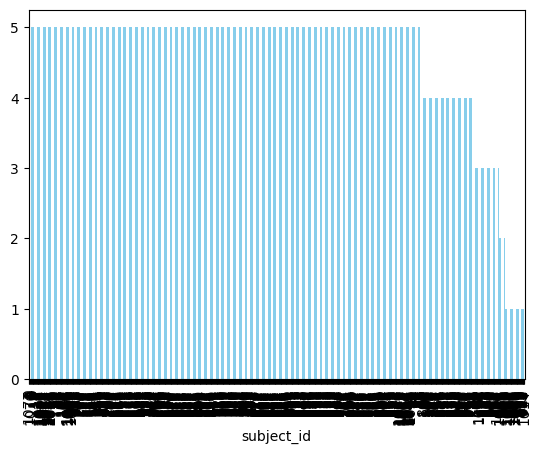

In [96]:
import matplotlib.pyplot as plt
hear_features_df.subject_id.value_counts().plot(kind='bar', color='skyblue')

# Feature Comparison

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [4]:
df_extraction = pd.read_csv("data_full.csv")

df_extraction["qxr_radiologist"] = df_extraction["qxr_radiologist"].map(
    {"Normal": 0, "Abnormal": 1}
)

df_extraction = df_extraction.dropna(subset=["qxr_radiologist"])

df_extraction["audio_path"] = df_extraction["audio_file"].apply(
    lambda s: os.path.join("Merged", os.path.basename(s))
)

df_extraction = df_extraction[df_extraction["audio_path"].apply(os.path.exists)]
df_extraction = df_extraction.reset_index(drop=True)

# Load HeAR embeddings
hear_features_df = pd.read_csv("hear_segment_embeddings_full_2.csv")

print("Unique subject_id in embeddings:", hear_features_df["subject_id"].nunique())
print("Rows in df_extraction:", len(df_extraction))

# Confirm subject_id matches df_extraction index
missing_ids = set(hear_features_df["subject_id"].unique()) - set(df_extraction.index)

print("Any subject_id not in df_extraction index?:", missing_ids)

# Map subject_id -> StudyID
hear_features_df["StudyID"] = hear_features_df["subject_id"].map(
    df_extraction["StudyID"]
)

# Safety check
print("Any missing StudyID after mapping?:",
      hear_features_df["StudyID"].isna().sum())

Unique subject_id in embeddings: 1078
Rows in df_extraction: 1078
Any subject_id not in df_extraction index?: set()
Any missing StudyID after mapping?: 0


In [6]:
hear_features_df["StudyID"] = hear_features_df["subject_id"].map(
    df_extraction["StudyID"]
)

train_subjects_sparse = pd.read_csv("train_subjects_segment.csv", header=None)[0].tolist()
val_subjects_sparse   = pd.read_csv("val_subjects_segment.csv", header=None)[0].tolist()

train_ids = df.loc[train_subjects_sparse, "StudyID"].tolist()
val_ids   = df.loc[val_subjects_sparse, "StudyID"].tolist()

print("Train StudyIDs:", len(train_ids))
print("Val StudyIDs:", len(val_ids))

combined_df = hear_features_df.copy()

train_df = combined_df[
    combined_df["StudyID"].isin(train_ids)
].copy()

test_df = combined_df[
    combined_df["StudyID"].isin(val_ids)
].copy()

print("Train subjects present:", train_df["StudyID"].nunique())
print("Test subjects present:", test_df["StudyID"].nunique())

Train StudyIDs: 846
Val StudyIDs: 212
Train subjects present: 846
Test subjects present: 212


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),
    "SVM": SVC(C=1.0, kernel='rbf', probability=True)
}

def run_segment_model(train_data, test_data, feature_cols):

    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_data[feature_cols])
    X_test  = scaler.transform(test_data[feature_cols])

    y_train = train_data["label"]

    results = {}

    for name, model in baseline_models.items():

        model.fit(X_train, y_train)

        test_temp = test_data.copy()
        test_temp["prob"] = model.predict_proba(X_test)[:,1]

        # Subject-level aggregation
        subject_results = test_temp.groupby("StudyID").agg(
            prob_abnormal=("prob","mean"),
            label=("label","first")
        ).reset_index()

        subject_results["final_pred"] = (
            subject_results["prob_abnormal"] >= 0.5
        ).astype(int)

        results[name] = (
            subject_results["label"].values,
            subject_results["final_pred"].values,
            subject_results["prob_abnormal"].values,
            subject_results["StudyID"].values
        )

    return results

## Hear Embeddings Only

In [8]:
hear_cols = [c for c in combined_df.columns if c.startswith("hear_")]

train_hear = train_df[['StudyID','segment_id','label'] + hear_cols]
test_hear  = test_df[['StudyID','segment_id','label'] + hear_cols]
results_hear = run_segment_model(train_hear, test_hear, hear_cols)

## Hear PCA

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale embeddings (train only)
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(train_df[hear_cols])
X_test_scaled  = scaler_pca.transform(test_df[hear_cols])

# Retain 96% variance (you can adjust to 0.95–0.99)
pca = PCA(n_components=0.96, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("PCA components:", pca.n_components_)
print("Variance retained:", pca.explained_variance_ratio_.sum())

# Rebuild DataFrames with StudyID + label
train_pca = pd.DataFrame(X_train_pca)
test_pca  = pd.DataFrame(X_test_pca)

for src, dest in [(train_df, train_pca), (test_df, test_pca)]:
    dest["StudyID"]   = src["StudyID"].values
    dest["segment_id"] = src["segment_id"].values
    dest["label"]     = src["label"].values

pca_cols = [c for c in train_pca.columns if c not in ["StudyID","segment_id","label"]]

results_pca = run_segment_model(train_pca, test_pca, pca_cols)

PCA components: 142
Variance retained: 0.960205745708181


## Hear + Acoustic (Autoencoded)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Scale first (train only)
scaler_ae = StandardScaler()
X_train_ae = scaler_ae.fit_transform(train_df[hear_cols])
X_test_ae  = scaler_ae.transform(test_df[hear_cols])

input_dim = X_train_ae.shape[1]
latent_dim = 128   # safer compression than 128

class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

model = AE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_ae, dtype=torch.float32)),
    batch_size=64,
    shuffle=True
)

# Train
for epoch in range(40):
    for (xb,) in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        recon, _ = model(xb)
        loss = loss_fn(recon, xb)
        loss.backward()
        optimizer.step()

# Extract latent representations
model.eval()
with torch.no_grad():
    _, latent_train = model(torch.tensor(X_train_ae, dtype=torch.float32).to(device))
    _, latent_test  = model(torch.tensor(X_test_ae, dtype=torch.float32).to(device))

train_latent = pd.DataFrame(latent_train.cpu().numpy())
test_latent  = pd.DataFrame(latent_test.cpu().numpy())

for src, dest in [(train_df, train_latent), (test_df, test_latent)]:
    dest["StudyID"]   = src["StudyID"].values
    dest["segment_id"] = src["segment_id"].values
    dest["label"]     = src["label"].values

ae_cols = [c for c in train_latent.columns if c not in ["StudyID","segment_id","label"]]

results_ae = run_segment_model(train_latent, test_latent, ae_cols)

## Add demographics

In [11]:
demo_cols = [
    'Age','Sex','Diabetes','BMI','Breathsounds','Breathdifficulty',
    'Durationofcough','Priortb','Hemoptysis','Heartrate',
    'Temperature','Weightloss','Smokedinlastweek',
    'Fever','Nightsweats'
]

# --- Recreate engineered / encoded columns in df_extraction ---

# Sex encoding (if needed)
if df_extraction["Sex"].dtype == object:
    df_extraction["Sex"] = df_extraction["Sex"].map({"Male": 0, "Female": 1})

# Diabetes encoding
if df_extraction["Diabetes"].dtype == object:
    df_extraction["Diabetes"] = df_extraction["Diabetes"].map(
        {"Non Diabetic": 0, "Diabetic": 1}
    )

# Binary symptom columns
bin_cols = [
    "Breathsounds","Breathdifficulty","Priortb","Hemoptysis",
    "Weightloss","Smokedinlastweek","Fever","Nightsweats"
]

for col in bin_cols:
    if df_extraction[col].dtype == object:
        df_extraction[col] = df_extraction[col].map({"Yes": 1, "No": 0})

# Recompute BMI if missing
if "BMI" not in df_extraction.columns:
    df_extraction["BMI"] = np.round(
        df_extraction["Weight"] / (0.01 * df_extraction["Height"])**2,
        2
    )
    
demographics_df = df_extraction.set_index("StudyID")[demo_cols]

train_ae_demo = train_latent.merge(
    demographics_df,
    left_on="StudyID",
    right_index=True,
    how="left"
)

test_ae_demo = test_latent.merge(
    demographics_df,
    left_on="StudyID",
    right_index=True,
    how="left"
)

# Drop missing demo rows
train_ae_demo = train_ae_demo.dropna(subset=demo_cols)
test_ae_demo  = test_ae_demo.dropna(subset=demo_cols)

train_ae_demo.columns = train_ae_demo.columns.astype(str)
test_ae_demo.columns  = test_ae_demo.columns.astype(str)

feature_cols_ae_demo = [
    c for c in train_ae_demo.columns
    if c not in ["StudyID","segment_id","label"]
]

results_ae_demo = run_segment_model(
    train_ae_demo,
    test_ae_demo,
    feature_cols_ae_demo
)

In [12]:
train_pca.columns = train_pca.columns.astype(str)
test_pca.columns  = test_pca.columns.astype(str)

train_pca_demo = train_pca.merge(
    demographics_df,
    left_on="StudyID",
    right_index=True,
    how="left"
)

test_pca_demo = test_pca.merge(
    demographics_df,
    left_on="StudyID",
    right_index=True,
    how="left"
)

# Drop rows missing demo values
train_pca_demo = train_pca_demo.dropna(subset=demo_cols)
test_pca_demo  = test_pca_demo.dropna(subset=demo_cols)

feature_cols_pca_demo = [
    c for c in train_pca_demo.columns
    if c not in ["StudyID","segment_id","label"]
]


results_pca_demo = run_segment_model(
    train_pca_demo,
    test_pca_demo,
    feature_cols_pca_demo
)

In [13]:
def extract_metrics(results_dict, label):
    
    rows = []
    
    for model_name, result_tuple in results_dict.items():
        
        # Now unpack 4 values
        y_true, y_pred, y_prob, study_ids = result_tuple
        
        rows.append({
            "Embedding": label,
            "Model": model_name,
            "AUC": roc_auc_score(y_true, y_prob)
        })
    
    return pd.DataFrame(rows)

comparison_df = pd.concat([
    extract_metrics(results_hear, "HeAR"),
    extract_metrics(results_pca, "HeAR_PCA"),
    extract_metrics(results_pca_demo, "HeAR_PCA+Demo"),
    extract_metrics(results_ae, "HeAR_AE128"),
    extract_metrics(results_ae_demo, "HeAR_AE128+Demo")
], ignore_index=True)

comparison_df.sort_values(["Model"], ascending=[True])

,Embedding,Model,AUC
0,HeAR,Logistic Regression,0.743214
3,HeAR_PCA,Logistic Regression,0.758750
6,HeAR_PCA+Demo,Logistic Regression,0.809911
9,HeAR_AE128,Logistic Regression,0.748393
12,HeAR_AE128+Demo,Logistic Regression,0.811607
1,HeAR,Random Forest,0.719018
4,HeAR_PCA,Random Forest,0.741250
7,HeAR_PCA+Demo,Random Forest,0.822143
10,HeAR_AE128,Random Forest,0.721161
13,HeAR_AE128+Demo,Random Forest,0.821786


## Visualizations

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
import pandas as pd
import numpy as np


def plot_confusion_matrices(models_results, title=""):
    
    n_models = len(models_results)
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models,4))
    
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, result_tuple) in enumerate(models_results.items()):
        
        y_true, y_pred, y_prob, _ = result_tuple
        
        cm = confusion_matrix(y_true, y_pred)
        
        sns.heatmap(cm,
                    annot=True,
                    fmt='d',
                    cmap='Blues',
                    xticklabels=['Normal','Abnormal'],
                    yticklabels=['Normal','Abnormal'],
                    ax=axes[idx])
        
        axes[idx].set_title(model_name)
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    
def plot_roc_curves(results_dict, figsize=(6, 4), title="ROC Curves", save_npz_path=None):
    plt.figure(figsize=figsize)
    pack = {}

    for model_name, res in results_dict.items():
        # res is length 4 for HeAR: (y_true, y_pred, y_prob, extra)
        y_true, y_pred, y_prob = res[:3]

        y_true = np.asarray(y_true)
        y_prob = np.asarray(y_prob)

        fpr, tpr, thr = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, linewidth=2.2, label=f"{model_name} (AUC={roc_auc:.3f})")

        safe = str(model_name).replace(" ", "_").replace("/", "_")
        pack[f"{safe}__y_true"] = y_true
        pack[f"{safe}__y_prob"] = y_prob
        pack[f"{safe}__fpr"] = fpr
        pack[f"{safe}__tpr"] = tpr
        pack[f"{safe}__thr"] = thr
        pack[f"{safe}__auc"] = np.array([roc_auc])

    plt.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.7)
    plt.xlim(0, 1); plt.ylim(0, 1.05)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right", fontsize=8.5, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if save_npz_path:
        np.savez(save_npz_path, **pack)
        print(f"✓ Saved ROC arrays to: {save_npz_path}")

    return pack

def calculate_metrics(y_true, y_pred, y_prob):
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    return {
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "Accuracy": accuracy,
        "AUC": roc_auc
    }


def create_metrics_table(models_results):
    
    rows = []
    
    for model_name, result_tuple in models_results.items():
        
        y_true, y_pred, y_prob, _ = result_tuple
        
        metrics = calculate_metrics(y_true, y_pred, y_prob)
        metrics["Model"] = model_name
        rows.append(metrics)
    
    df_metrics = pd.DataFrame(rows).set_index("Model")
    
    styled = df_metrics.style.format("{:.3f}")\
        .background_gradient(cmap="RdYlGn", subset=["AUC","Accuracy"])
    
    return df_metrics, styled

def analyze_performance_by_group(df_meta, subject_results_df, analysis_cols):

    merged = df_meta.set_index("StudyID").merge(
        subject_results_df,
        left_index=True,
        right_index=True,
        how="inner"
    )

    rows = []

    # Overall
    cm = confusion_matrix(merged['y_true'], merged['y_pred'], labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "Group": "Overall",
        "Level": "All",
        "N": len(merged),
        "Sensitivity": tp/(tp+fn) if (tp+fn)>0 else 0,
        "Specificity": tn/(tn+fp) if (tn+fp)>0 else 0,
        "Accuracy": (tp+tn)/(tp+tn+fp+fn),
        "AUC": roc_auc_score(merged['y_true'], merged['y_prob'])
    })

    for col in analysis_cols:

        if col not in merged.columns:
            continue

        temp_df = merged.copy()

        if col in ['Age','BMI','Durationofcough','Heartrate','Temperature']:

            if col == "Age":
                bins = [0,25,35,50,65,100]
                labels = ['<25','25-35','35-50','50-65','65+']
            elif col == "BMI":
                bins = [0,18.5,25,30,35,100]
                labels = ['<18.5','18.5-25','25-30','30-35','35+']
            elif col == "Durationofcough":
                bins = [0,7,14,30,1000]
                labels = ['<1wk','1-2wk','2-4wk','4wk+']
            elif col == "Heartrate":
                bins = [0,70,85,100,200]
                labels = ['<70','70-85','85-100','100+']
            elif col == "Temperature":
                bins = [0,36.5,37.5,38.5,100]
                labels = ['<36.5','36.5-37.5','37.5-38.5','38.5+']

            temp_df[f"{col}_binned"] = pd.cut(
                temp_df[col],
                bins=bins,
                labels=labels,
                include_lowest=True
            )

            group_col = f"{col}_binned"

        else:
            group_col = col

        for level, sub in temp_df.groupby(group_col, observed=True):

            if len(sub) < 2:
                continue

            cm = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0,1])
            tn, fp, fn, tp = cm.ravel()

            auc_val = (
                roc_auc_score(sub['y_true'], sub['y_prob'])
                if sub['y_true'].nunique()==2
                else np.nan
            )

            rows.append({
                "Group": col,
                "Level": str(level),
                "N": len(sub),
                "Sensitivity": tp/(tp+fn) if (tp+fn)>0 else 0,
                "Specificity": tn/(tn+fp) if (tn+fp)>0 else 0,
                "Accuracy": (tp+tn)/(tp+tn+fp+fn),
                "AUC": auc_val
            })

    return pd.DataFrame(rows)

def style_breakdown_table(breakdown_df):

    return breakdown_df.style.format({
        "N":"{:,.0f}",
        "Sensitivity":"{:.3f}",
        "Specificity":"{:.3f}",
        "Accuracy":"{:.3f}",
        "AUC":"{:.3f}"
    }).background_gradient(
        cmap="RdYlGn",
        subset=["AUC","Sensitivity","Specificity","Accuracy"],
        vmin=0,
        vmax=1
    )

def build_subject_results_df(result_tuple):

    y_true, y_pred, y_prob, study_ids = result_tuple

    return pd.DataFrame({
        "StudyID": study_ids,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }).set_index("StudyID")

In [15]:
def visualize_pipeline(results_dict, pipeline_name):

    print(f"\n{'='*60}")
    print(f"📊 {pipeline_name}")
    print(f"{'='*60}")

    plot_confusion_matrices(results_dict, title=f"{pipeline_name} - Confusion Matrices")
    plot_roc_curves(results_dict, title=f"{pipeline_name} - ROC Curves", save_npz_path=f"roc_hear_{pipeline_name}.npz")

    metrics_df, styled = create_metrics_table(results_dict)
    display(styled)

    return metrics_df


# ------------------------------------------------------------
# 5️⃣ RUN FOR ALL PIPELINES
# ------------------------------------------------------------

all_pipelines = {
    "HeAR": results_hear,
    "HeAR_PCA": results_pca,
    "HeAR_PCA_Demo": results_pca_demo,
    "HeAR_AE128": results_ae,
    "HeAR_AE128_Demo": results_ae_demo
}

all_metrics = {}
for name, results_dict in all_pipelines.items():
    all_metrics[name] = visualize_pipeline(results_dict, name)


📊 HeAR
✓ Saved ROC arrays to: roc_hear_HeAR.npz


,Sensitivity,Specificity,PPV,NPV,Accuracy,AUC
Model,,,,,,
Logistic Regression,0.770,0.545,0.602,0.726,0.651,0.743
Random Forest,0.720,0.571,0.600,0.696,0.642,0.719
SVM,0.780,0.491,0.578,0.714,0.627,0.723



📊 HeAR_PCA
✓ Saved ROC arrays to: roc_hear_HeAR_PCA.npz


,Sensitivity,Specificity,PPV,NPV,Accuracy,AUC
Model,,,,,,
Logistic Regression,0.740,0.554,0.597,0.705,0.642,0.759
Random Forest,0.750,0.536,0.591,0.706,0.637,0.741
SVM,0.820,0.509,0.599,0.760,0.656,0.753



📊 HeAR_PCA_Demo
✓ Saved ROC arrays to: roc_hear_HeAR_PCA_Demo.npz


,Sensitivity,Specificity,PPV,NPV,Accuracy,AUC
Model,,,,,,
Logistic Regression,0.770,0.723,0.713,0.779,0.745,0.810
Random Forest,0.720,0.768,0.735,0.754,0.745,0.822
SVM,0.770,0.741,0.726,0.783,0.755,0.817



📊 HeAR_AE128
✓ Saved ROC arrays to: roc_hear_HeAR_AE128.npz


,Sensitivity,Specificity,PPV,NPV,Accuracy,AUC
Model,,,,,,
Logistic Regression,0.740,0.554,0.597,0.705,0.642,0.748
Random Forest,0.720,0.580,0.605,0.699,0.646,0.721
SVM,0.800,0.500,0.588,0.737,0.642,0.739



📊 HeAR_AE128_Demo
✓ Saved ROC arrays to: roc_hear_HeAR_AE128_Demo.npz


,Sensitivity,Specificity,PPV,NPV,Accuracy,AUC
Model,,,,,,
Logistic Regression,0.760,0.714,0.704,0.769,0.736,0.812
Random Forest,0.750,0.750,0.728,0.771,0.750,0.822
SVM,0.750,0.705,0.694,0.760,0.726,0.812


In [16]:
analysis_cols = [
    'Country','Sex','Age','BMI','Breathsounds','Breathdifficulty',
    'Diabetes','Durationofcough','Priortb','Hemoptysis',
    'Heartrate','Temperature','Weightloss',
    'Smokedinlastweek','Fever','Nightsweats'
]

for pipeline_name, results_dict in all_pipelines.items():

    print("\n" + "="*80)
    print(f"📊 DEMOGRAPHIC BREAKDOWN: {pipeline_name}")
    print("="*80)

    for model_name, result_tuple in results_dict.items():

        print("\n" + "-"*60)
        print(f"Model: {model_name}")
        print("-"*60)

        # Build subject-level dataframe
        subject_results_df = build_subject_results_df(result_tuple)

        # Compute breakdown
        breakdown_df = analyze_performance_by_group(
            df_extraction,
            subject_results_df,
            analysis_cols
        )

        # Display styled table
        display(style_breakdown_table(breakdown_df))


📊 DEMOGRAPHIC BREAKDOWN: HeAR

------------------------------------------------------------
Model: Logistic Regression
------------------------------------------------------------


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.770,0.545,0.651,0.743
1,Country,IN,13,1.000,0.444,0.615,0.806
2,Country,PH,52,0.700,0.500,0.615,0.664
3,Country,SA,33,0.846,0.650,0.727,0.831
4,Country,UG,56,0.588,0.667,0.643,0.652
5,Country,VN,58,0.861,0.318,0.655,0.823
6,Sex,0,105,0.812,0.415,0.657,0.712
7,Sex,1,107,0.694,0.620,0.645,0.730
8,Age,<25,40,0.643,0.500,0.550,0.626
9,Age,25-35,42,0.706,0.680,0.690,0.739



------------------------------------------------------------
Model: Random Forest
------------------------------------------------------------


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.720,0.571,0.642,0.719
1,Country,IN,13,1.000,0.444,0.615,0.694
2,Country,PH,52,0.567,0.636,0.596,0.673
3,Country,SA,33,0.769,0.850,0.818,0.854
4,Country,UG,56,0.471,0.564,0.536,0.517
5,Country,VN,58,0.917,0.318,0.690,0.826
6,Sex,0,105,0.875,0.195,0.610,0.698
7,Sex,1,107,0.444,0.789,0.673,0.653
8,Age,<25,40,0.429,0.538,0.500,0.473
9,Age,25-35,42,0.647,0.680,0.667,0.715



------------------------------------------------------------
Model: SVM
------------------------------------------------------------


...

,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.760,0.714,0.736,0.812
1,Country,IN,13,1.000,0.444,0.615,0.833
2,Country,PH,52,0.733,0.818,0.769,0.812
3,Country,SA,33,0.538,0.850,0.727,0.808
4,Country,UG,56,0.706,0.846,0.804,0.742
5,Country,VN,58,0.861,0.364,0.672,0.823
6,Sex,0,105,0.844,0.561,0.733,0.821
7,Sex,1,107,0.611,0.803,0.738,0.745
8,Age,<25,40,0.643,0.885,0.800,0.819
9,Age,25-35,42,0.471,0.840,0.690,0.664



------------------------------------------------------------
Model: Random Forest
------------------------------------------------------------


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.750,0.750,0.750,0.822
1,Country,IN,13,1.000,0.333,0.538,0.639
2,Country,PH,52,0.733,0.818,0.769,0.829
3,Country,SA,33,0.538,0.950,0.788,0.881
4,Country,UG,56,0.471,0.846,0.732,0.724
5,Country,VN,58,0.944,0.500,0.776,0.876
6,Sex,0,105,0.875,0.512,0.733,0.831
7,Sex,1,107,0.528,0.887,0.766,0.763
8,Age,<25,40,0.786,0.731,0.750,0.799
9,Age,25-35,42,0.471,0.880,0.714,0.725



------------------------------------------------------------
Model: SVM
------------------------------------------------------------


,Group,Level,N,Sensitivity,Specificity,Accuracy,AUC
0,Overall,All,212,0.750,0.705,0.726,0.812
1,Country,IN,13,1.000,0.556,0.692,0.778
2,Country,PH,52,0.733,0.864,0.788,0.826
3,Country,SA,33,0.615,0.900,0.788,0.812
4,Country,UG,56,0.588,0.795,0.732,0.710
5,Country,VN,58,0.861,0.273,0.638,0.850
6,Sex,0,105,0.828,0.610,0.743,0.827
7,Sex,1,107,0.611,0.761,0.710,0.737
8,Age,<25,40,0.643,0.885,0.800,0.830
9,Age,25-35,42,0.471,0.760,0.643,0.631


## Poster Figures

In [17]:
"""
Poster figures — soft palette, stacked bars showing demographic lift,
subgroup heatmaps. Run: python generate_poster_figures_v2.py
"""
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linestyle":     "--",
    "grid.color":         "#d1d5db",
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
})

# Soft colour palette
C1 = "#639cf1"  # Full
C2 = "#7ed362"  # Segmented
C3 = "#f17d63"  # HeAR
DEMO_ALPHA = 0.28     # lighter fill extension for +demo

# ══════════════════════════════════════════════════════════════════════════════
# FIG 1  — AUC bar chart: audio-only base bar + lighter extension for +demo
# ══════════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=(13, 5.2))

# (group label, audio-only AUC, +demo AUC, colour)
entries = [
    ("Full\nRF",   0.6444, 0.7784, C1),
    ("Full\nSVM",  0.6535, 0.7886, C1),
    ("Full\nLR",   0.6457, 0.8164, C1),
    ("Seg.\nRF",   0.6613, 0.8079, C2),
    ("Seg.\nSVM",  0.6695, 0.8179, C2),
    ("Seg.\nLR",   0.7511, 0.8411, C2),
    ("HeAR\nRF",   0.6581, 0.8201, C3),
    ("HeAR\nSVM",  0.6640, 0.8103, C3),
    ("HeAR\nLR",   0.6851, 0.8154, C3),
]

labels    = [e[0] for e in entries]
audio_auc = [e[1] for e in entries]
demo_auc  = [e[2] for e in entries]
colors    = [e[3] for e in entries]
x = np.arange(len(entries))
W = 0.52

for i, (a, d, c) in enumerate(zip(audio_auc, demo_auc, colors)):
    # Base bar — audio only
    ax.bar(i, a, W, color=c, alpha=0.82, zorder=3)
    # Extension — demographic lift (lighter, hatched)
    ax.bar(i, d - a, W, bottom=a, color=c, alpha=DEMO_ALPHA, zorder=3,
        hatch="///", edgecolor=c, linewidth=0.6)
    ax.text(i, a + (d-a)/2, f"+{(d-a):.03f}", ha="center", va="center",
            fontsize=7.5, color="#111827")

# Dividers between pipeline groups
for xpos in [2.5, 5.5]:
    ax.axvline(xpos, color="#9ca3af", linewidth=1, linestyle="--", zorder=2)

# Group banners
for xmid, txt, col in [(1, "Pipeline 1 · Full Audio", C1),
                        (4, "Pipeline 2 · Segmented",  C2),
                        (7, "Pipeline 3 · HeAR",       C3)]:
    ax.text(xmid, 0.895, txt, ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=col,
            transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9.5)
ax.set_ylim(0, 0.95)
ax.set_ylabel("AUROC", fontsize=11)
ax.set_title("AUROC by Pipeline, Model, and Feature Set\n(lighter bar extension = gain from adding clinical demographics)",
             fontsize=12, fontweight="bold", pad=12)
ax.axhline(0.50, color="#ef4444", linewidth=1.1, linestyle=":", zorder=2,
           label="AUROC = 0.50")

# Legend
solid  = mpatches.Patch(facecolor="#9ca3af", alpha=0.85, label="Audio features only")
extend = mpatches.Patch(facecolor="#9ca3af", alpha=DEMO_ALPHA, label="+ Clinical demographics")
p1p = mpatches.Patch(color=C1, label="Pipeline 1 (Full)")
p2p = mpatches.Patch(color=C2, label="Pipeline 2 (Segmented)")
p3p = mpatches.Patch(color=C3, label="Pipeline 3 (HeAR)")
ax.legend(handles=[solid, extend, p1p, p2p, p3p],
          fontsize=8.5, loc="lower right", framealpha=0.9, ncol=2)

fig1.tight_layout()
fig1.savefig("fig1_auc_stacked.png", dpi=200, bbox_inches="tight")
fig1.savefig("fig1_auc_stacked.pdf", dpi=200, bbox_inches="tight")
print("✓ fig1_auc_stacked.png")
print("✓ fig1_auc_stacked.pdf")

# ═══════════════════════════════════════════════════════════════════════
# FIG 1B — Demographic lift only (ΔAUROC) per model + pipeline
# ═══════════════════════════════════════════════════════════════════════
fig1b, ax = plt.subplots(figsize=(10.5, 3.8))

df = pd.DataFrame(entries, columns=["label","audio_auc","demo_auc","color"])
df["delta"] = df["demo_auc"] - df["audio_auc"]

x = np.arange(len(df))
ax.bar(x, df["delta"], color=df["color"], alpha=0.85, zorder=3)

for i, v in enumerate(df["delta"]):
    ax.text(i, v + 0.005, f"{v:+.03f}", ha="center", va="bottom",
            fontsize=8, color="#374151")

for xpos in [2.5, 5.5]:
    ax.axvline(xpos, color="#9ca3af", linewidth=1, linestyle="--", zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(df["label"], fontsize=9)
ax.set_ylabel("ΔAUROC (Demographics − Audio)", fontsize=11)
ax.set_title("Clinical demographics provide the largest performance gains",
             fontsize=12, fontweight="bold", pad=10)
ax.axhline(0, color="#111827", linewidth=0.8)

fig1b.tight_layout()
fig1b.savefig("fig1b_demo_lift_only.png", dpi=250, bbox_inches="tight")
fig1b.savefig("fig1b_demo_lift_only.pdf", dpi=250, bbox_inches="tight")
print("✓ fig1b_demo_lift_only.png")
print("✓ fig1b_demo_lift_only.pdf")

# ══════════════════════════════════════════════════════════════════════════════
# FIG 2  — Best model metrics: Sens / Spec / Acc / AUC with same stacked style
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(9, 4.8))

metrics = ["Sensitivity", "Specificity", "Accuracy", "AUROC"]
# (audio-only, +demo) per metric per pipeline
best = {
    "Full LR":     {"audio": (0.646, 0.604, 0.604, 0.646),
                    "demo":  (0.707, 0.752, 0.728, 0.816)},
    "Seg. LR":     {"audio": (0.743, 0.633, 0.692, 0.751),
                    "demo":  (0.761, 0.735, 0.749, 0.841)},
    "HeAR+PCA RF": {"audio": (0.658, 0.630, 0.644, 0.676),
                    "demo":  (0.760, 0.670, 0.720, 0.820)},
}

pipe_colors = {"Full LR": C1, "Seg. LR": C2, "HeAR+PCA RF": C3}
x = np.arange(len(metrics))
W = 0.22
offsets = [-W, 0, W]

for (name, vals), offset in zip(best.items(), offsets):
    col = pipe_colors[name]
    a_vals = vals["audio"]
    d_vals = vals["demo"]
    xi = x + offset
    ax.bar(xi, a_vals, W*0.9, color=col, alpha=0.82, zorder=3, label=name)
    # extension
    ax.bar(xi, [d-a for d, a in zip(d_vals, a_vals)], W*0.9,
           bottom=a_vals, color=col, alpha=DEMO_ALPHA, zorder=3)
    for j, (a, d) in enumerate(zip(a_vals, d_vals)):
        ax.text(xi[j], d + 0.008, f"{d:.2f}", ha="center", fontsize=7.5, color="#374151")

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 0.95)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Best Model per Pipeline — Key Metrics\n(lighter extension = gain from demographics)",
             fontsize=12, fontweight="bold", pad=12)
ax.axhline(0.50, color="#ef4444", linewidth=1.1, linestyle=":", zorder=2)

solid2  = mpatches.Patch(facecolor="#9ca3af", alpha=0.82, label="Audio only")
extend2 = mpatches.Patch(facecolor="#9ca3af", alpha=DEMO_ALPHA, label="+ Demographics")
p1h = mpatches.Patch(color=C1, label="Full Audio · LR")
p2h = mpatches.Patch(color=C2, label="Segmented · LR (best)")
p3h = mpatches.Patch(color=C3, label="HeAR+PCA · RF")
ax.legend(handles=[solid2, extend2, p1h, p2h, p3h],
          fontsize=8.5, loc="lower right", framealpha=0.9, ncol=2)

fig2.tight_layout()
fig2.savefig("fig2_best_metrics.png", dpi=200, bbox_inches="tight")
fig2.savefig("fig2_best_metrics.pdf", bbox_inches="tight")
print("✓ fig2_best_metrics.png")
print("✓ fig2_best_metrics.pdf")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 3  — Subgroup heatmap: Sensitivity & Specificity (Segmented LR, no demo)
# ══════════════════════════════════════════════════════════════════════════════
subgroup_data = {
    # (Sensitivity, Specificity, Accuracy, n)
    "Country: IN":              (0.750, 0.667, 0.692, 13),
    "Country: PH":              (0.600, 0.636, 0.615, 52),
    "Country: SA":              (0.692, 0.450, 0.545, 33),
    "Country: UG":              (0.529, 0.769, 0.696, 56),
    "Country: VN":              (0.972, 0.182, 0.672, 58),
    "Sex: Female":              (0.766, 0.488, 0.657, 105),
    "Sex: Male":                (0.694, 0.606, 0.636, 107),
    "Age: Q1 (youngest)":      (0.556, 0.686, 0.642, 53),
    "Age: Q2":                  (0.714, 0.559, 0.618, 55),
    "Age: Q3":                  (0.714, 0.615, 0.667, 54),
    "Age: Q4 (oldest)":        (0.879, 0.235, 0.660, 50),
    "BMI: Q1 (lowest)":        (0.789, 0.562, 0.722, 54),
    "BMI: Q2":                  (0.733, 0.455, 0.615, 52),
    "BMI: Q3":                  (0.750, 0.545, 0.623, 53),
    "BMI: Q4 (highest)":       (0.583, 0.634, 0.623, 53),
    "Breathsounds: No":        (0.781, 0.522, 0.647, 133),
    "Breathsounds: Yes":       (0.667, 0.628, 0.646, 79),
    "Breath difficulty: No":   (0.711, 0.485, 0.577, 111),
    "Breath difficulty: Yes":  (0.764, 0.674, 0.723, 101),
    "HIV: Negative":           (0.745, 0.560, 0.649, 194),
    "HIV: Positive":           (0.667, 0.583, 0.611, 18),
    "Smoked: No":              (0.778, 0.567, 0.657, 169),
    "Smoked: Yes":             (0.643, 0.533, 0.605, 43),
}

rows  = list(subgroup_data.keys())
sens  = [v[0] for v in subgroup_data.values()]
spec  = [v[1] for v in subgroup_data.values()]
acc   = [v[2] for v in subgroup_data.values()]
ns    = [v[3] for v in subgroup_data.values()]

heat_df = pd.DataFrame({
    "Sensitivity": sens,
    "Specificity": spec,
    "Accuracy":    acc,
    "n":           ns,
}, index=rows)

fig3, ax3 = plt.subplots(figsize=(8, 10))
sns.heatmap(
    heat_df[["Sensitivity", "Specificity", "Accuracy"]],
    annot=True, fmt=".2f", linewidths=0.5,
    cmap="RdYlGn", vmin=0.2, vmax=1.0,
    annot_kws={"size": 9},
    ax=ax3,
    cbar_kws={"shrink": 0.6, "label": "Score"}
)
# Add n column as text
for i, n in enumerate(ns):
    ax3.text(3.55, i + 0.5, str(n), ha="left", va="center",
             fontsize=8.5, color="#374151")
ax3.text(3.55, -0.4, "n", ha="left", va="center",
         fontsize=9, fontweight="bold", color="#111827")

ax3.set_title("Subgroup Analysis — Segmented Pipeline · Logistic Regression (Audio Only)",
              fontsize=11, fontweight="bold", pad=14)
ax3.set_xlabel("")
ax3.tick_params(axis="y", labelsize=9.5)
ax3.tick_params(axis="x", labelsize=10)

fig3.tight_layout()
fig3.savefig("fig3_subgroup_heatmap_seg.png", dpi=200, bbox_inches="tight")
fig3.savefig("fig3_subgroup_heatmap_seg.pdf", bbox_inches="tight")
print("✓ fig3_subgroup_heatmap_seg.png and .pdf")


# ═══════════════════════════════════════════════════════════════════════
# FIG 3B — Country breakdown (Segmented LR audio-only) as paired bars
# ═══════════════════════════════════════════════════════════════════════
country_rows = [k for k in subgroup_data.keys() if k.startswith("Country")]
country = [k.split(": ")[1] for k in country_rows]
sens_c = [subgroup_data[k][0] for k in country_rows]
spec_c = [subgroup_data[k][1] for k in country_rows]
n_c    = [subgroup_data[k][3] for k in country_rows]

fig3b, ax = plt.subplots(figsize=(7.6, 3.8))
x = np.arange(len(country))
w = 0.36
ax.bar(x - w/2, sens_c, width=w, label="Sensitivity", alpha=0.85, color=C2, zorder=3)
ax.bar(x + w/2, spec_c, width=w, label="Specificity", alpha=0.35, color=C2, zorder=3)

for i, n in enumerate(n_c):
    ax.text(i, 0.02, f"n={n}", ha="center", va="bottom", fontsize=8, color="#374151")

ax.set_xticks(x)
ax.set_xticklabels(country, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Segmented LR (Audio-only): Country heterogeneity", fontsize=11, fontweight="bold")
ax.legend(framealpha=0.9, fontsize=9, loc="upper right")
ax.axhline(0.5, linestyle=":", linewidth=1, color="#9ca3af")

fig3b.tight_layout()
fig3b.savefig("fig3b_country_bars_seg.png", dpi=250, bbox_inches="tight")
fig3b.savefig("fig3b_country_bars_seg.pdf", bbox_inches="tight")
print("✓ fig3b_country_bars_seg.png and .pdf")

# ══════════════════════════════════════════════════════════════════════════════
# FIG 4  — Same heatmap for Full Audio RF (from slides)
# ══════════════════════════════════════════════════════════════════════════════
full_data = {
    "Country: IN":             (1.000, 0.300, 0.632, 19),
    "Country: PH":             (0.444, 0.739, 0.580, 50),
    "Country: SA":             (0.611, 0.667, 0.639, 36),
    "Country: UG":             (0.538, 0.743, 0.656, 61),
    "Country: VN":             (1.000, 0.000, 0.720, 50),
    "Sex: Female":             (0.750, 0.559, 0.691, 110),
    "Sex: Male":               (0.625, 0.591, 0.604, 106),
    "Age: Q1 (youngest)":     (0.526, 0.600, 0.574, 54),
    "Age: Q2":                 (0.724, 0.704, 0.714, 56),
    "Age: Q3":                 (0.600, 0.542, 0.574, 54),
    "Age: Q4 (oldest)":       (0.868, 0.357, 0.731, 52),
    "BMI: Q1 (lowest)":       (0.636, 0.700, 0.648, 54),
    "BMI: Q2":                 (0.710, 0.478, 0.611, 54),
    "BMI: Q3":                 (0.846, 0.500, 0.667, 54),
    "BMI: Q4 (highest)":      (0.667, 0.667, 0.667, 54),
    "Breathsounds: No":       (0.810, 0.554, 0.694, 144),
    "Breathsounds: Yes":      (0.486, 0.629, 0.556, 72),
    "Breath difficulty: No":  (0.773, 0.588, 0.692, 117),
    "Breath difficulty: Yes": (0.620, 0.571, 0.596, 99),
    "HIV: Negative":          (0.736, 0.551, 0.651, 195),
    "HIV: Positive":          (0.400, 0.800, 0.600, 20),
    "Smoked: No":             (0.738, 0.568, 0.651, 172),
    "Smoked: Yes":            (0.625, 0.667, 0.636, 44),
}

rows2  = list(full_data.keys())
heat2  = pd.DataFrame({
    "Sensitivity": [v[0] for v in full_data.values()],
    "Specificity": [v[1] for v in full_data.values()],
    "Accuracy":    [v[2] for v in full_data.values()],
    "n":           [v[3] for v in full_data.values()],
}, index=rows2)

fig4, ax4 = plt.subplots(figsize=(8, 10))
sns.heatmap(
    heat2[["Sensitivity", "Specificity", "Accuracy"]],
    annot=True, fmt=".2f", linewidths=0.5,
    cmap="RdYlGn", vmin=0.2, vmax=1.0,
    annot_kws={"size": 9},
    ax=ax4,
    cbar_kws={"shrink": 0.6, "label": "Score"}
)
for i, n in enumerate([v[3] for v in full_data.values()]):
    ax4.text(3.55, i + 0.5, str(n), ha="left", va="center",
             fontsize=8.5, color="#374151")
ax4.text(3.55, -0.4, "n", ha="left", va="center",
         fontsize=9, fontweight="bold", color="#111827")

ax4.set_title("Subgroup Analysis — Full Audio Pipeline · Random Forest (Audio Only)",
              fontsize=11, fontweight="bold", pad=14)
ax4.set_xlabel("")
ax4.tick_params(axis="y", labelsize=9.5)
ax4.tick_params(axis="x", labelsize=10)

fig4.tight_layout()
fig4.savefig("fig4_subgroup_heatmap_full.png", dpi=200, bbox_inches="tight")
fig4.savefig("fig4_subgroup_heatmap_full.pdf", bbox_inches="tight")
print("✓ fig4_subgroup_heatmap_full.png")

print("\nAll figures saved.")

✓ fig1_auc_stacked.png
✓ fig1_auc_stacked.pdf
✓ fig1b_demo_lift_only.png
✓ fig1b_demo_lift_only.pdf
✓ fig2_best_metrics.png
✓ fig2_best_metrics.pdf
✓ fig3_subgroup_heatmap_seg.png and .pdf
✓ fig3b_country_bars_seg.png and .pdf
✓ fig4_subgroup_heatmap_full.png

All figures saved.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

C1 = "#639cf1"  # Full
C2 = "#7ed362"  # Segmented
C3 = "#f17d63"  # HeAR

BASE = Path(".")  # set to folder containing the .npz files if needed

AUDIO_ONLY_FILES = {
    "Full (handcrafted)":      ("roc_full_acoustic_only.npz", C1),
    "Segmented events":        ("roc_segmented_acoustic_only.npz", C2),
    "HeAR (PCA embeddings)":   ("roc_hear_HeAR_PCA.npz", C3),
}

WITH_DEMO_FILES = {
    "Full Cough Recording":      ("roc_full_pipeline.npz", C1),
    "Segmented Coughs Events":        ("roc_segmented_acoustic_plus_demo.npz", C2),
    "HeAR (PCA embeddings)":   ("roc_hear_HeAR_PCA_Demo.npz", C3),
}

def load_rocs(npz_path: Path):
    """Load fpr/tpr/auc arrays for all models stored in Option A .npz export."""
    z = np.load(npz_path)
    keys = list(z.keys())
    models = sorted({k.split("__")[0] for k in keys})
    rocs = {}
    for m in models:
        rocs[m] = {
            "fpr": z[f"{m}__fpr"],
            "tpr": z[f"{m}__tpr"],
            "auc": float(z[f"{m}__auc"][0]),
        }
    return rocs

def pick_best_model(rocs: dict):
    """Return (best_model_name, best_dict) by max AUC."""
    best = max(rocs.items(), key=lambda kv: kv[1]["auc"])
    return best[0], best[1]

def plot_best_panel(ax, file_map, title):
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="#9ca3af", alpha=0.8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title, fontsize=12, fontweight="bold")

    for pipeline_label, (fname, color) in file_map.items():
        rocs = load_rocs(BASE / fname)
        best_name, best = pick_best_model(rocs)

        ax.plot(
            best["fpr"], best["tpr"],
            linewidth=2.0, color=color, alpha=0.95,
            label=f"{pipeline_label}: {best_name} (AUC={best['auc']:.3f})"
        )

    ax.legend(loc="lower right", fontsize=9, framealpha=0.95)

# --- Create figure ---
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))

plot_best_panel(
    axes[0], AUDIO_ONLY_FILES,
    "Audio only"
)

plot_best_panel(
    axes[1], WITH_DEMO_FILES,
    "Audio + demographics"
)

fig.suptitle("Best-performing ROC curves across pipelines",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()

fig.savefig("figR_best_rocs_side_by_side.png", dpi=300, bbox_inches="tight")
fig.savefig("figR_best_rocs_side_by_side.pdf", bbox_inches="tight")
print("✓ Saved figR_best_rocs_side_by_side.png and .pdf")

✓ Saved figR_best_rocs_side_by_side.png and .pdf
